In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Thales_Group_Manufacturing.csv")

# Display first 5 rows
df.head()
#df.info()

,Date,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,01-01-2025,00:00:00,39,Idle,74.138,3.501,8.612,10.651,0.208,7.751,477.657,0.345,14.965,Low
1,01-01-2025,00:01:00,29,Active,84.265,3.356,2.269,29.112,2.228,4.989,398.175,0.770,7.678,Low
2,01-01-2025,00:02:00,15,Active,44.280,2.080,6.144,18.357,1.639,0.457,108.075,0.987,8.198,Low
3,01-01-2025,00:03:00,43,Active,40.569,0.298,4.068,29.154,1.161,4.583,329.579,0.983,2.741,Medium
4,01-01-2025,00:04:00,8,Idle,75.064,0.346,6.226,34.029,4.797,2.288,159.114,0.573,12.101,Low


In [2]:
#1 Validate Sensor Ranges and units
# Describe data (min, max, mean)
print(df.describe())

# Check abnormal values manually

# Temperature (example range 0–100°C)
print(df[(df['Temperature_C'] < 0) | (df['Temperature_C'] > 100)])

# Vibration (example 0–100 Hz)
print(df[(df['Vibration_Hz'] < 0) | (df['Vibration_Hz'] > 100)])

# Power consumption (example > 0)
print(df[df['Power_Consumption_kW'] < 0])

          Machine_ID  Temperature_C   Vibration_Hz  Power_Consumption_kW  \
count  100000.000000  100000.000000  100000.000000         100000.000000   
mean       25.499330      60.041460       2.549959              5.745929   
std        14.389439      17.323239       1.414127              2.451271   
min         1.000000      30.000000       0.100000              1.500000   
25%        13.000000      45.031500       1.323000              3.627000   
50%        25.000000      60.033500       2.549000              5.755000   
75%        38.000000      74.967250       3.776000              7.860000   
max        50.000000      89.999000       5.000000             10.000000   

       Network_Latency_ms  Packet_Loss_%  Quality_Control_Defect_Rate_%  \
count        100000.00000  100000.000000                  100000.000000   
mean             25.55562       2.493418                       5.008806   
std              14.12076       1.443273                       2.883666   
min            

In [3]:
#2 Handling Missing or incosnsistent time records
# Check missing values
print(df.isnull().sum())

# Fill missing values (example: forward fill)
df.fillna(method='ffill', inplace=True)

# Combine Date + Timestamp into one column
# Replace all '-' with '/'
df['Date'] = df['Date'].astype(str).str.replace('-', '/')

# Convert safely with dayfirst=True
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Timestamp'],
    errors='coerce',
    dayfirst=True
)

# Check if any failed conversions
print(df[df['Datetime'].isnull()][['Date', 'Timestamp']])

# Sort by time
df = df.sort_values(by='Datetime')

print(df[['Date', 'Timestamp', 'Datetime']].head())

Date                             0
Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss_%                    0
Quality_Control_Defect_Rate_%    0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate_%                     0
Efficiency_Status                0
dtype: int64


C:\Users\Rohit\AppData\Local\Temp\ipykernel_41956\3110725992.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Empty DataFrame
Columns: [Date, Timestamp]
Index: []
         Date Timestamp            Datetime
0  01/01/2025  00:00:00 2025-01-01 00:00:00
1  01/01/2025  00:01:00 2025-01-01 00:01:00
2  01/01/2025  00:02:00 2025-01-01 00:02:00
3  01/01/2025  00:03:00 2025-01-01 00:03:00
4  01/01/2025  00:04:00 2025-01-01 00:04:00


In [4]:
# Remove extra spaces and make uniform
df['Machine_ID'] = df['Machine_ID'].astype(str).str.strip().str.upper()

df['Operation_Mode'] = df['Operation_Mode'].astype(str).str.strip().str.lower()

# Check unique values
print(df['Machine_ID'].unique())
print(df['Operation_Mode'].unique())


['39' '29' '15' '43' '8' '21' '19' '23' '11' '24' '36' '40' '3' '22' '2'
 '44' '30' '38' '33' '12' '25' '49' '27' '42' '28' '16' '47' '37' '7' '9'
 '18' '4' '14' '50' '26' '20' '35' '17' '6' '34' '10' '31' '48' '45' '41'
 '1' '5' '13' '32' '46']
['idle' 'active' 'maintenance']


In [5]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

In [6]:
#Machine Level sensor Health Analysis
#Analyze Temperature,vibration and power patterns per machine.
import matplotlib.pyplot as plt
import seaborn as sns

# Average sensor values per machine
machine_sensor = df.groupby('Machine_ID')[['Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW']].mean()

print(machine_sensor)

            Temperature_C  Vibration_Hz  Power_Consumption_kW
Machine_ID                                                   
1               59.489320      2.581578              5.821217
10              60.424115      2.545863              5.801357
11              60.264830      2.543883              5.764898
12              59.851596      2.500051              5.712417
13              59.897617      2.540377              5.651545
14              60.297563      2.573266              5.743542
15              59.679127      2.547693              5.788249
16              60.501857      2.554848              5.810824
17              60.537234      2.554587              5.758279
18              59.884223      2.540198              5.678348
19              59.763928      2.555860              5.750156
2               59.814415      2.534771              5.724922
20              60.120693      2.561139              5.806563
21              60.026190      2.544124              5.839563
22      

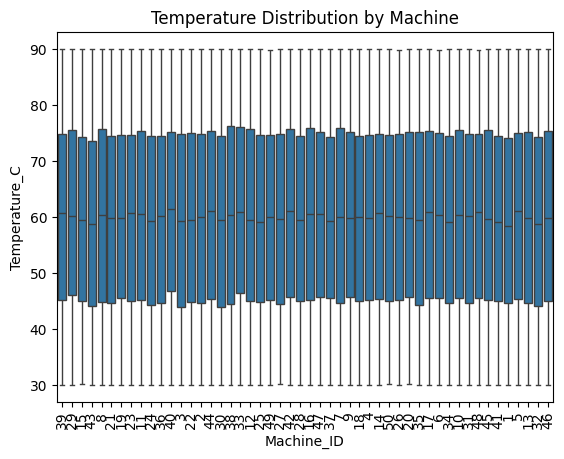

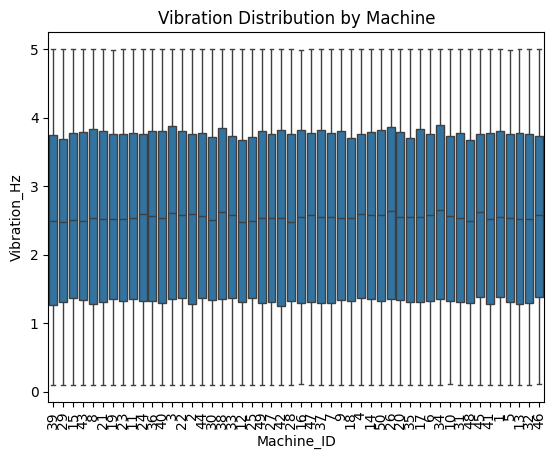

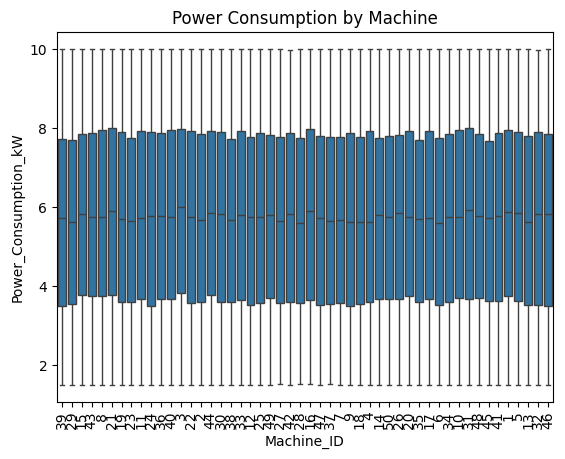

In [7]:
#graph
# Temperature distribution
plt.figure()
sns.boxplot(x='Machine_ID', y='Temperature_C', data=df)
plt.xticks(rotation=90)
plt.title("Temperature Distribution by Machine")
plt.show()

# Vibration distribution
plt.figure()
sns.boxplot(x='Machine_ID', y='Vibration_Hz', data=df)
plt.xticks(rotation=90)
plt.title("Vibration Distribution by Machine")
plt.show()

# Power consumption
plt.figure()
sns.boxplot(x='Machine_ID', y='Power_Consumption_kW', data=df)
plt.xticks(rotation=90)
plt.title("Power Consumption by Machine")
plt.show()

In [8]:
# Thresholds
temp_limit = 80
vibration_limit = 70

# Machines crossing limits
high_temp = df[df['Temperature_C'] > temp_limit]
high_vibration = df[df['Vibration_Hz'] > vibration_limit]

print("High Temperature Machines:")
print(high_temp['Machine_ID'].value_counts())

print("High Vibration Machines:")
print(high_vibration['Machine_ID'].value_counts())

High Temperature Machines:
Machine_ID
38    381
16    372
42    369
40    368
5     357
7     355
2     354
17    354
23    352
22    351
29    350
45    350
33    350
48    349
44    347
8     346
13    344
26    341
47    341
28    340
9     338
14    338
41    338
20    337
46    337
19    336
21    334
10    334
27    333
36    333
39    331
25    330
11    327
6     326
12    325
31    325
35    323
30    322
18    320
32    316
1     316
24    315
37    315
15    313
34    310
50    307
3     306
4     303
49    303
43    294
Name: count, dtype: int64
High Vibration Machines:
Series([], Name: count, dtype: int64)


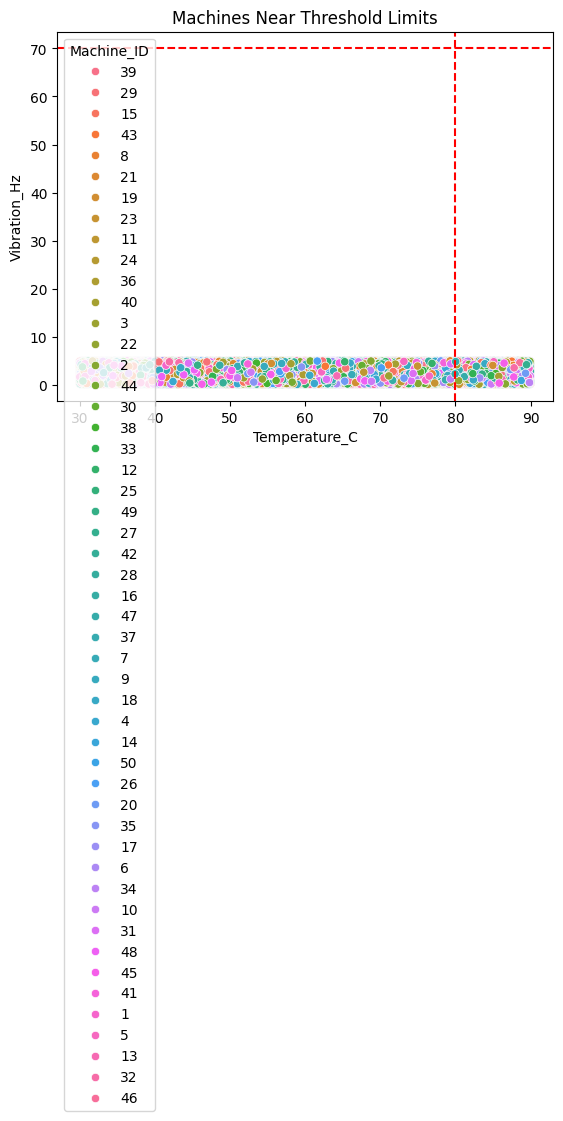

In [9]:
#graph
plt.figure()
sns.scatterplot(x='Temperature_C', y='Vibration_Hz', hue='Machine_ID', data=df)
plt.axvline(temp_limit, color='r', linestyle='--')
plt.axhline(vibration_limit, color='r', linestyle='--')
plt.title("Machines Near Threshold Limits")
plt.show()

In [10]:
# Mean values by operation mode
mode_analysis = df.groupby('Operation_Mode')[['Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW']].mean()

print(mode_analysis)

                Temperature_C  Vibration_Hz  Power_Consumption_kW
Operation_Mode                                                   
active              60.057067      2.552978              5.751227
idle                60.015608      2.537169              5.734926
maintenance         59.983327      2.554513              5.730708


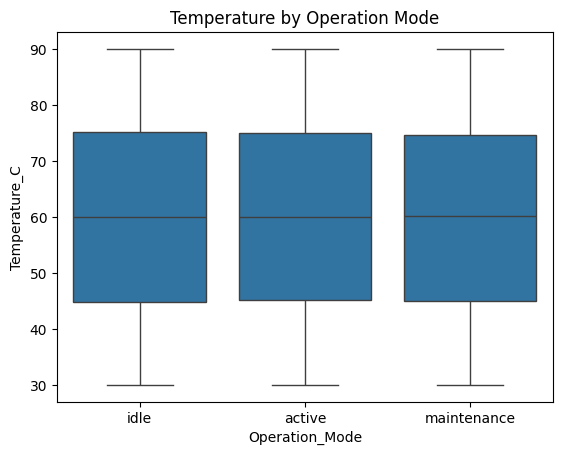

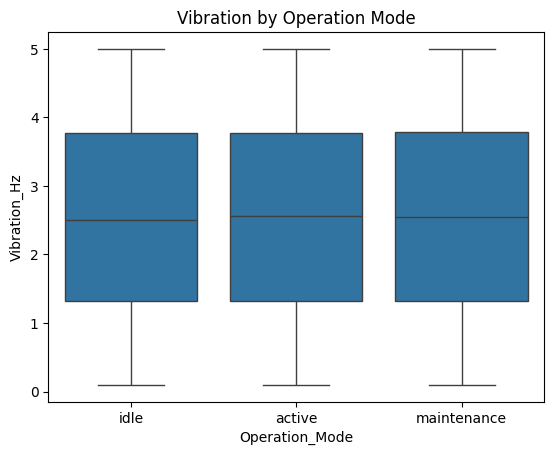

In [11]:
#graph
sns.boxplot(x='Operation_Mode', y='Temperature_C', data=df)
plt.title("Temperature by Operation Mode")
plt.show()

sns.boxplot(x='Operation_Mode', y='Vibration_Hz', data=df)
plt.title("Vibration by Operation Mode")
plt.show()

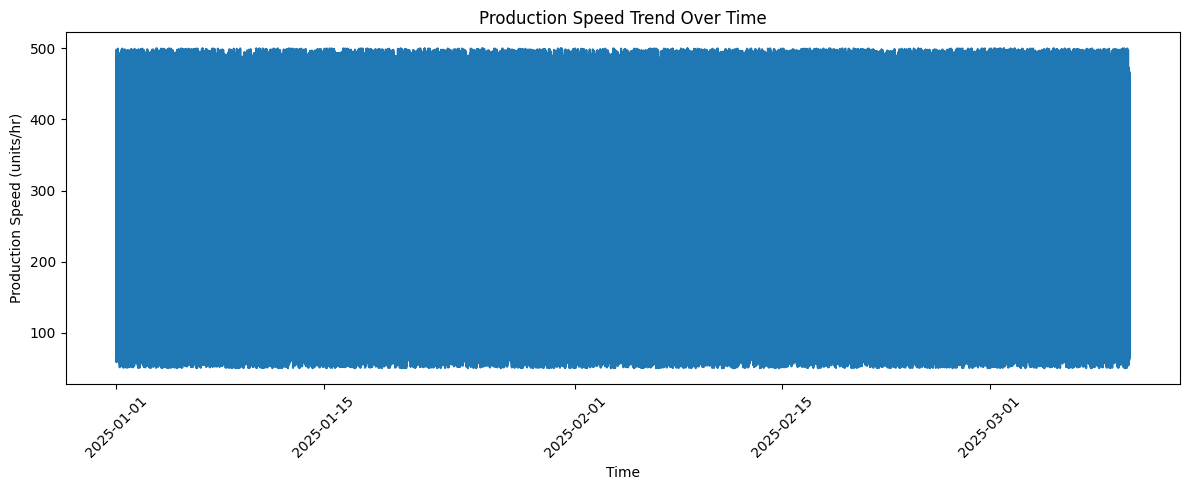

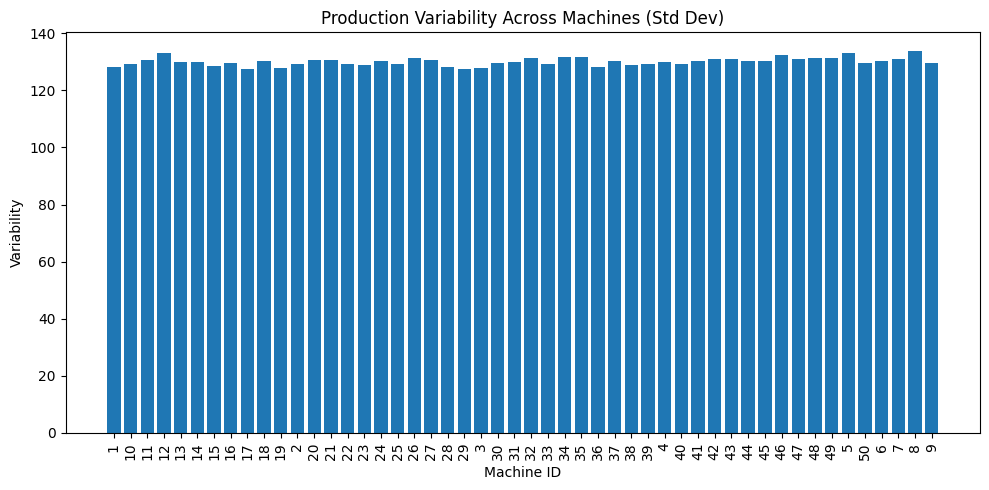

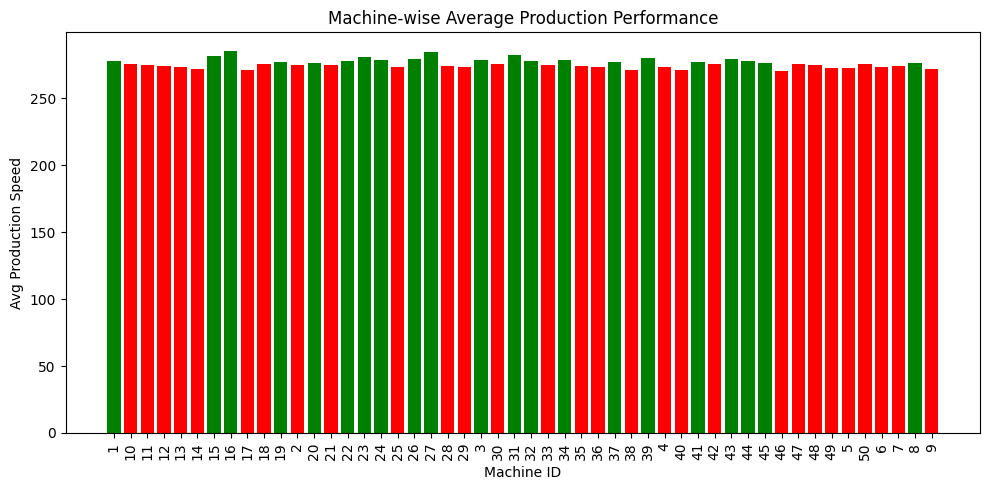

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Create Datetime safely
# -----------------------------
df['Datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Timestamp'].astype(str),
    errors='coerce',      # invalid formats → NaT
    dayfirst=True         # handles 13-01-2025 format
)

# -----------------------------
# 2. Remove invalid rows
# -----------------------------
df = df.dropna(subset=['Datetime'])

# -----------------------------
# 3. Sort data
# -----------------------------
df = df.sort_values('Datetime')

# =========================================================
# 1️⃣ Production Speed Trend (Overall)
# =========================================================
plt.figure(figsize=(12,5))
plt.plot(df['Datetime'], df['Production_Speed_units_per_hr'])
plt.title("Production Speed Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Production Speed (units/hr)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# 2️⃣ Output Consistency Across Machines
# =========================================================
machine_stats = df.groupby('Machine_ID')['Production_Speed_units_per_hr'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10,5))
plt.bar(machine_stats['Machine_ID'], machine_stats['std'])
plt.title("Production Variability Across Machines (Std Dev)")
plt.xlabel("Machine ID")
plt.ylabel("Variability")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# =========================================================
# 3️⃣ Identify Underperforming Machines
# =========================================================
overall_mean = df['Production_Speed_units_per_hr'].mean()

machine_perf = df.groupby('Machine_ID')['Production_Speed_units_per_hr'].mean().reset_index()

machine_perf['Status'] = machine_perf['Production_Speed_units_per_hr'].apply(
    lambda x: 'Underperforming' if x < overall_mean else 'Normal'
)

plt.figure(figsize=(10,5))
colors = machine_perf['Status'].map({'Underperforming': 'red', 'Normal': 'green'})

plt.bar(machine_perf['Machine_ID'], machine_perf['Production_Speed_units_per_hr'], color=colors)

plt.title("Machine-wise Average Production Performance")
plt.xlabel("Machine ID")
plt.ylabel("Avg Production Speed")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

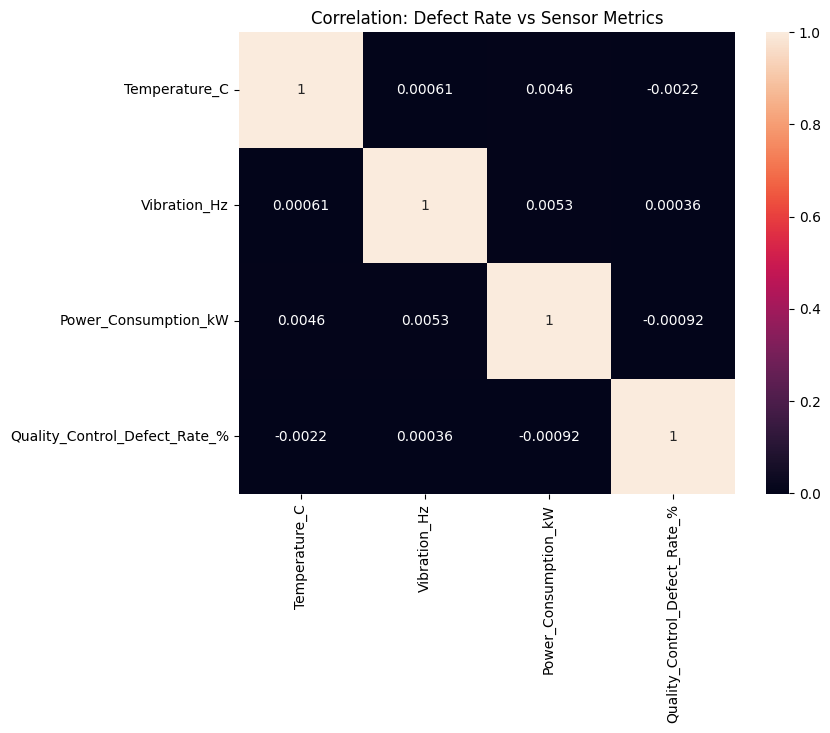

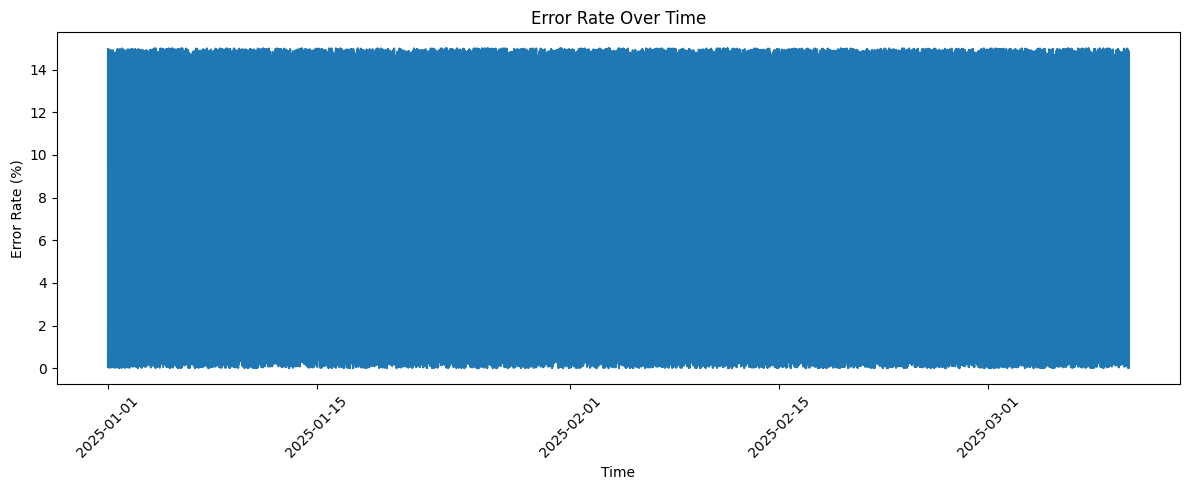

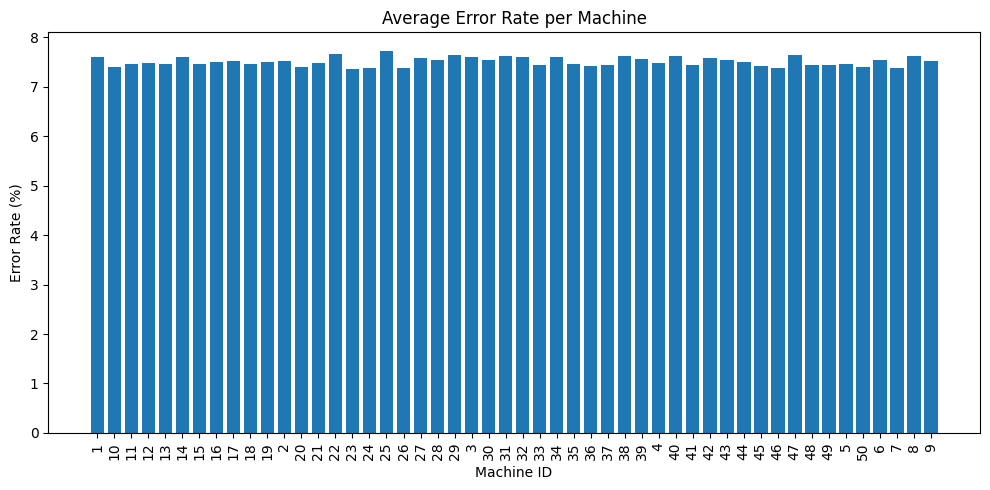

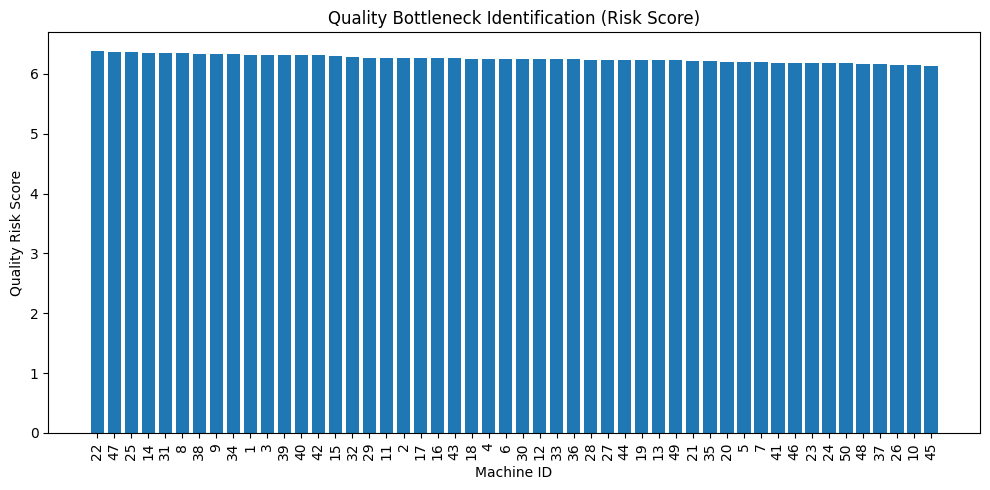

In [14]:
#Quality and Error analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Datetime Handling (Robust)
# -----------------------------
df['Datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Timestamp'].astype(str),
    errors='coerce',
    dayfirst=True
)

df = df.dropna(subset=['Datetime'])
df = df.sort_values('Datetime')

# =========================================================
# 1️⃣ Correlation: Defect Rate vs Sensor Behavior
# =========================================================

corr_cols = [
    'Temperature_C',
    'Vibration_Hz',
    'Power_Consumption_kW',
    'Quality_Control_Defect_Rate_%'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation: Defect Rate vs Sensor Metrics")
plt.show()

# =========================================================
# 2️⃣ Error Rate Spikes by Machine and Time
# =========================================================

plt.figure(figsize=(12,5))
plt.plot(df['Datetime'], df['Error_Rate_%'])
plt.title("Error Rate Over Time")
plt.xlabel("Time")
plt.ylabel("Error Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Machine-wise error comparison
machine_error = df.groupby('Machine_ID')['Error_Rate_%'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.bar(machine_error['Machine_ID'], machine_error['Error_Rate_%'])
plt.title("Average Error Rate per Machine")
plt.xlabel("Machine ID")
plt.ylabel("Error Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# =========================================================
# 3️⃣ Identify Quality Bottlenecks
# =========================================================

# Combine defect rate + error rate
quality_metrics = df.groupby('Machine_ID')[[
    'Quality_Control_Defect_Rate_%',
    'Error_Rate_%'
]].mean().reset_index()

# Create a simple risk score (average of both)
quality_metrics['Quality_Risk_Score'] = (
    quality_metrics['Quality_Control_Defect_Rate_%'] +
    quality_metrics['Error_Rate_%']
) / 2

# Sort machines by risk
quality_metrics = quality_metrics.sort_values(by='Quality_Risk_Score', ascending=False)

plt.figure(figsize=(10,5))
plt.bar(quality_metrics['Machine_ID'], quality_metrics['Quality_Risk_Score'])
plt.title("Quality Bottleneck Identification (Risk Score)")
plt.xlabel("Machine ID")
plt.ylabel("Quality Risk Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [15]:
#Efficiency Status Distribution
import pandas as pd

# -----------------------------
# 1. Datetime Handling
# -----------------------------
df['Datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Timestamp'].astype(str),
    errors='coerce',
    dayfirst=True
)

df = df.dropna(subset=['Datetime'])

# -----------------------------
# 2. Standardize Operation Mode
# -----------------------------
df['Operation_Mode'] = df['Operation_Mode'].str.strip().str.lower()

mode_mapping = {
    'normal': 'Normal',
    'high-load': 'High Load',
    'high load': 'High Load',
    'low-load': 'Low Load',
    'low load': 'Low Load'
}

df['Operation_Mode'] = df['Operation_Mode'].replace(mode_mapping)

# =========================================================
# 1️⃣ Efficiency Distribution (High / Medium / Low)
# =========================================================
eff_distribution = df['Efficiency_Status'].value_counts().reset_index()
eff_distribution.columns = ['Efficiency_Status', 'Count']

eff_distribution['Percentage'] = (
    eff_distribution['Count'] / eff_distribution['Count'].sum() * 100
)

print("Efficiency Distribution:")
print(eff_distribution)

# =========================================================
# 2️⃣ Efficiency by Machine
# =========================================================
eff_by_machine = pd.crosstab(df['Machine_ID'], df['Efficiency_Status'])

print("\nEfficiency by Machine:")
print(eff_by_machine)

# =========================================================
# 3️⃣ Efficiency by Operation Mode
# =========================================================
eff_by_mode = pd.crosstab(df['Operation_Mode'], df['Efficiency_Status'])

print("\nEfficiency by Operation Mode:")
print(eff_by_mode)

# =========================================================
# 4️⃣ Optional: Efficiency Summary for Reporting
# =========================================================
summary = {
    "Total Records": len(df),
    "High Efficiency %": eff_distribution[eff_distribution['Efficiency_Status'] == 'High']['Percentage'].values,
    "Medium Efficiency %": eff_distribution[eff_distribution['Efficiency_Status'] == 'Medium']['Percentage'].values,
    "Low Efficiency %": eff_distribution[eff_distribution['Efficiency_Status'] == 'Low']['Percentage'].values
}

print("\nSummary:")
print(summary)

Efficiency Distribution:
  Efficiency_Status  Count  Percentage
0               Low  77825      77.825
1            Medium  19189      19.189
2              High   2986       2.986

Efficiency by Machine:
Efficiency_Status  High   Low  Medium
Machine_ID                           
1                    55  1473     388
10                   63  1580     379
11                   61  1511     379
12                   51  1516     388
13                   68  1578     394
14                   45  1533     363
15                   71  1543     413
16                   64  1531     415
17                   59  1617     385
18                   61  1601     369
19                   62  1531     411
2                    58  1596     387
20                   55  1499     416
21                   57  1602     393
22                   73  1577     381
23                   69  1594     429
24                   73  1512     399
25                   57  1562     379
26                   64  1588     4

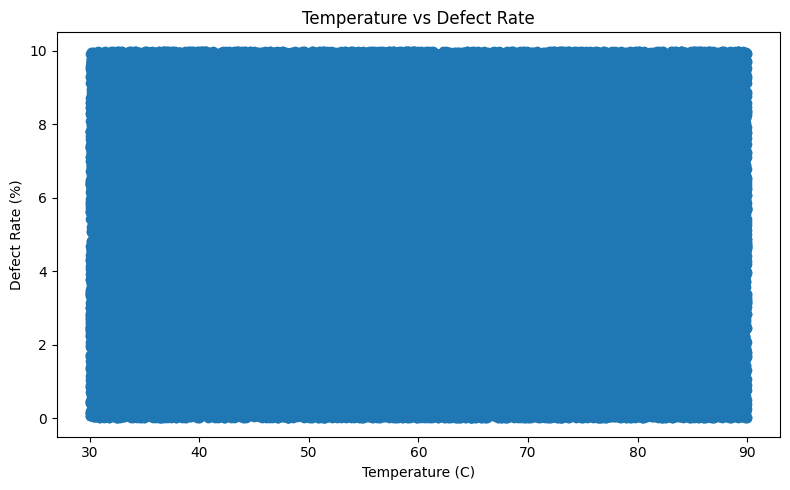

Temperature vs Defect Correlation: -0.00223751748520949


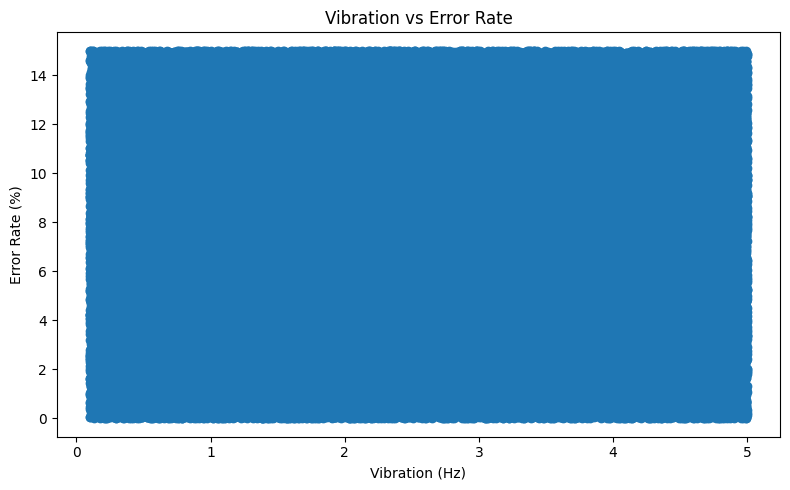

Vibration vs Error Correlation: 0.004578992820156519


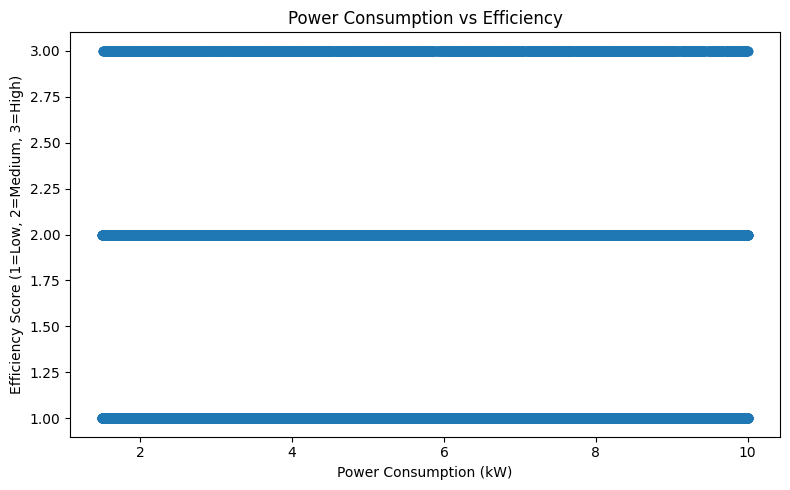

Power vs Efficiency Correlation: 0.0011910823490156833


In [16]:
# Cross Metric Diagnostics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Datetime Handling
# -----------------------------
df['Datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Timestamp'].astype(str),
    errors='coerce',
    dayfirst=True
)

df = df.dropna(subset=['Datetime'])

# =========================================================
# 1️⃣ Temperature vs Defect Rate
# =========================================================
plt.figure(figsize=(8,5))
plt.scatter(df['Temperature_C'], df['Quality_Control_Defect_Rate_%'])
plt.title("Temperature vs Defect Rate")
plt.xlabel("Temperature (C)")
plt.ylabel("Defect Rate (%)")
plt.tight_layout()
plt.show()

# Correlation
temp_defect_corr = df[['Temperature_C', 'Quality_Control_Defect_Rate_%']].corr().iloc[0,1]
print("Temperature vs Defect Correlation:", temp_defect_corr)

# =========================================================
# 2️⃣ Vibration vs Error Rate
# =========================================================
plt.figure(figsize=(8,5))
plt.scatter(df['Vibration_Hz'], df['Error_Rate_%'])
plt.title("Vibration vs Error Rate")
plt.xlabel("Vibration (Hz)")
plt.ylabel("Error Rate (%)")
plt.tight_layout()
plt.show()

# Correlation
vib_error_corr = df[['Vibration_Hz', 'Error_Rate_%']].corr().iloc[0,1]
print("Vibration vs Error Correlation:", vib_error_corr)

# =========================================================
# 3️⃣ Power Consumption vs Efficiency Trade-off
# =========================================================

# Convert Efficiency_Status to numeric for analysis
eff_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['Efficiency_Score'] = df['Efficiency_Status'].map(eff_map)

plt.figure(figsize=(8,5))
plt.scatter(df['Power_Consumption_kW'], df['Efficiency_Score'])
plt.title("Power Consumption vs Efficiency")
plt.xlabel("Power Consumption (kW)")
plt.ylabel("Efficiency Score (1=Low, 2=Medium, 3=High)")
plt.tight_layout()
plt.show()

# Correlation
power_eff_corr = df[['Power_Consumption_kW', 'Efficiency_Score']].corr().iloc[0,1]
print("Power vs Efficiency Correlation:", power_eff_corr)

In [18]:
## Cleaned data saved
df.to_csv('Thales_Group_Manufacturing_cleaned_data.csv',index=False)
print("File successfully saved")

File successfully saved
